In [11]:
!nvidia-smi

Sun May 10 10:54:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |    4233MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.applications import Xception, VGG16, ResNet50

# GPU info
print("TensorFlow GPU devices:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

# Enable mixed precision (3x speedup on T4/L4 GPUs)
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled: float16")

TensorFlow GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
Mixed precision enabled: float16


In [13]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"
!chmod 600 /content/kaggle.json

if not os.path.exists('chest_xray/train'):
    print("📥 Downloading dataset...")
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    !unzip -q chest-xray-pneumonia.zip
    print("✅ Download complete!")
else:
    print("✅ Dataset already exists.")

# Verify structure
for split in ['train', 'val', 'test']:
    path = f'chest_xray/{split}'
    if os.path.exists(path):
        normal = len(os.listdir(f'{path}/NORMAL')) if os.path.exists(f'{path}/NORMAL') else 0
        pneumonia = len(os.listdir(f'{path}/PNEUMONIA')) if os.path.exists(f'{path}/PNEUMONIA') else 0
        print(f"  {split}: NORMAL={normal}, PNEUMONIA={pneumonia}")
    else:
        print(f"  ⚠️ {split} folder not found")

chmod: cannot access '/content/kaggle.json': No such file or directory
✅ Dataset already exists.
  train: NORMAL=1341, PNEUMONIA=3875
  val: NORMAL=8, PNEUMONIA=8
  test: NORMAL=234, PNEUMONIA=390


In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def create_dataset_from_lists(file_paths, labels, shuffle=True, augment=False):
    """Create dataset from pre-built file lists (allows proper splitting)."""
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=5000)  # Increased from 1000

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if augment:
        def augment_fn(img, label):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.1)
            return img, label
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# --- Get ALL training files and labels ---
train_normal = glob.glob('chest_xray/train/NORMAL/*')
train_pneumonia = glob.glob('chest_xray/train/PNEUMONIA/*')

all_train_paths = train_normal + train_pneumonia
all_train_labels = [0] * len(train_normal) + [1] * len(train_pneumonia)

print(f"Total train samples: {len(all_train_paths)}")
print(f"  NORMAL: {len(train_normal)} ({len(train_normal)/len(all_train_paths):.1%})")
print(f"  PNEUMONIA: {len(train_pneumonia)} ({len(train_pneumonia)/len(all_train_paths):.1%})")

# --- PROPER 80/10/10 SPLIT ---
from sklearn.model_selection import train_test_split

# First: 80% train, 20% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_train_labels  # Keeps class ratio in each split!
)

# Then: split temp into val (50%) and test (50%) → 10% each overall
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nAfter split:")
print(f"  Train: {len(train_paths)} ({len(train_paths)/len(all_train_paths):.1%})")
print(f"  Val: {len(val_paths)} ({len(val_paths)/len(all_train_paths):.1%})")
print(f"  Test: {len(test_paths)} ({len(test_paths)/len(all_train_paths):.1%})")

# Create datasets
train_ds = create_dataset_from_lists(train_paths, train_labels, shuffle=True, augment=True)
val_ds = create_dataset_from_lists(val_paths, val_labels, shuffle=False, augment=False)
test_ds = create_dataset_from_lists(test_paths, test_labels, shuffle=False, augment=False)

print(f"\n✅ Datasets ready!")
print(f"  Train batches: {len(train_paths)//BATCH_SIZE}")
print(f"  Val batches: {len(val_paths)//BATCH_SIZE}")
print(f"  Test batches: {len(test_paths)//BATCH_SIZE}")

Total train samples: 5216
  NORMAL: 1341 (25.7%)
  PNEUMONIA: 3875 (74.3%)

After split:
  Train: 4172 (80.0%)
  Val: 522 (10.0%)
  Test: 522 (10.0%)

✅ Datasets ready!
  Train batches: 130
  Val batches: 16
  Test batches: 16


In [15]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name='Custom_CNN')
    return model

def build_transfer_model(base_model_class, name):
    base = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name=name)
    return model

# Build all models
print("🏗️ Building models...")
custom_model = build_custom_cnn()
xception_model = build_transfer_model(Xception, 'Xception')
vgg_model = build_transfer_model(VGG16, 'VGG16')
resnet_model = build_transfer_model(ResNet50, 'ResNet50')

models_dict = {
    'Custom CNN': custom_model,
    'Xception': xception_model,
    'VGG16': vgg_model,
    'ResNet50': resnet_model
}

for name, model in models_dict.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    print(f"\n{name}:")
    model.summary()

🏗️ Building models...

Custom CNN:


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

...

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# In training loop:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    verbose=1
)
EPOCHS = 5
histories = {}

print("=" * 50)
print("TRAINING ALL MODELS")
print("=" * 50)

for name, model in models_dict.items():
    print(f"\n🚀 Training {name}...")
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        verbose=1
    )
    histories[name] = history
    print(f"✅ {name} complete!")

Class weights: {0: np.float64(1.9440820130475303), 1: np.float64(0.6731203614069055)}
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 368ms/step - accuracy: 0.5817 - loss: 0.6956 - val_accuracy: 0.8333 - val_loss: 0.5823
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 237ms/step - accuracy: 0.7069 - loss: 0.6037 - val_accuracy: 0.8333 - val_loss: 0.5597
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - accuracy: 0.7454 - loss: 0.5434 - val_accuracy: 0.8410 - val_loss: 0.4055
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 218ms/step - accuracy: 0.7907 - loss: 0.4886 - val_accuracy: 0.8161 - val_loss: 0.5265
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 228ms/step - accuracy: 0.8075 - loss: 0.4523 - val_accuracy: 0.8812 - val_loss: 0.3516
TRAINING ALL MODELS

🚀 Training Custom CNN...
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 301ms/step - accuracy: 0.7402 - loss: 0.5906 - val_accuracy: 0.7433 - val_loss: 0.5766
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 214ms/step - accuracy: 0.7428 - loss: 0.5815 

In [17]:
print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)

results = {}
for name, model in models_dict.items():
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    results[name] = test_acc
    print(f"{name:15s} - Test Accuracy: {test_acc*100:.2f}%")

best_model = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model} ({results[best_model]*100:.2f}%)")

FINAL RESULTS
Custom CNN      - Test Accuracy: 84.87%
Xception        - Test Accuracy: 94.44%
VGG16           - Test Accuracy: 94.64%
ResNet50        - Test Accuracy: 83.33%

🏆 Best Model: VGG16 (94.64%)


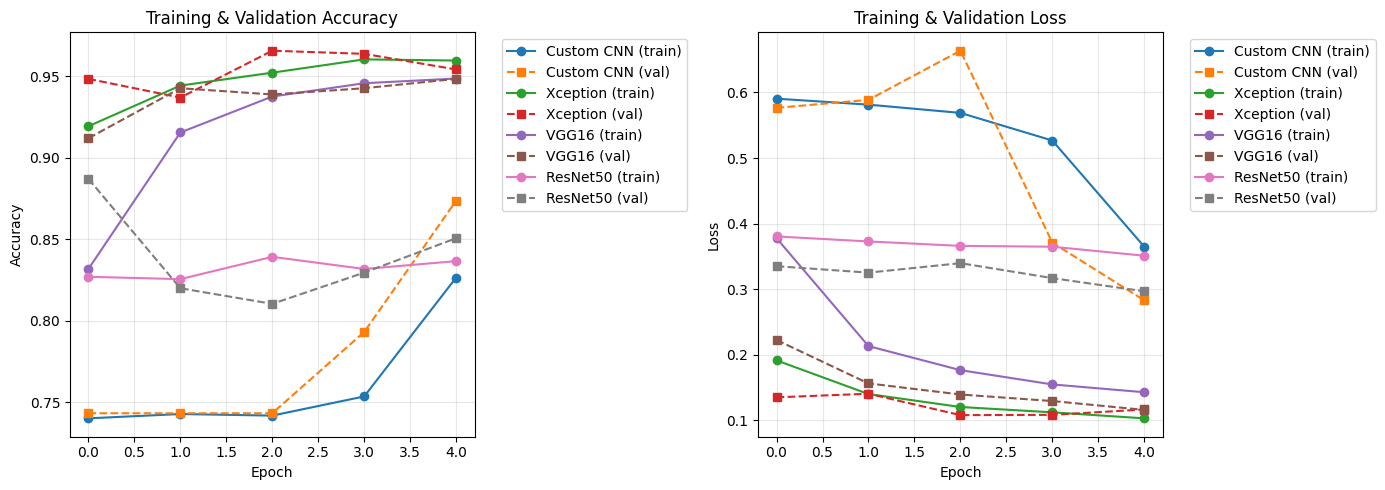

📊 Plot saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
for name, history in histories.items():
    axes[0].plot(history.history['accuracy'], marker='o', label=f'{name} (train)')
    axes[0].plot(history.history['val_accuracy'], marker='s', linestyle='--', label=f'{name} (val)')
axes[0].set_title('Training & Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Loss
for name, history in histories.items():
    axes[1].plot(history.history['loss'], marker='o', label=f'{name} (train)')
    axes[1].plot(history.history['val_loss'], marker='s', linestyle='--', label=f'{name} (val)')
axes[1].set_title('Training & Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot saved!")

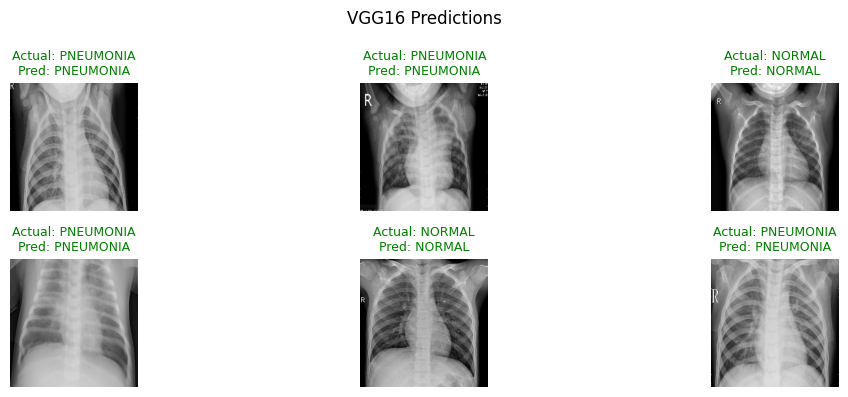


✅ All done! Best model: VGG16


In [19]:
def show_predictions(model, name, num_images=6):
    plt.figure(figsize=(12, 4))
    for images, labels in test_ds.take(1):
        preds = model.predict(images[:num_images], verbose=0)
        for i in range(num_images):
            plt.subplot(2, num_images//2, i+1)
            plt.imshow(images[i])
            actual = "PNEUMONIA" if labels[i] == 1 else "NORMAL"
            predicted = "PNEUMONIA" if preds[i][0] > 0.5 else "NORMAL"
            color = "green" if actual == predicted else "red"
            plt.title(f"Actual: {actual}\nPred: {predicted}", color=color, fontsize=9)
            plt.axis('off')
        plt.suptitle(f"{name} Predictions", fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{name.lower().replace(" ", "_")}_predictions.png', dpi=150, bbox_inches='tight')
        plt.show()
        break

show_predictions(models_dict[best_model], best_model)
print(f"\n✅ All done! Best model: {best_model}")

In [20]:
# Count classes in each split
for split in ['train', 'val', 'test']:
    normal = len(glob.glob(f'chest_xray/{split}/NORMAL/*'))
    pneumonia = len(glob.glob(f'chest_xray/{split}/PNEUMONIA/*'))
    total = normal + pneumonia
    print(f"{split}: NORMAL={normal} ({normal/total:.1%}), PNEUMONIA={pneumonia} ({pneumonia/total:.1%})")

train: NORMAL=1341 (25.7%), PNEUMONIA=3875 (74.3%)
val: NORMAL=8 (50.0%), PNEUMONIA=8 (50.0%)
test: NORMAL=234 (37.5%), PNEUMONIA=390 (62.5%)
